In [ ]:
# Task 1 - import the dataset
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

df = pd.read_csv("Simple linear regression.csv")
df

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83
...,...,...
95,1934,3.54
96,1861,3.58
97,1931,3.58
98,1933,3.59


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     100 non-null    int64  
 1   GPA     100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 SAT    0
GPA    0
dtype: int64


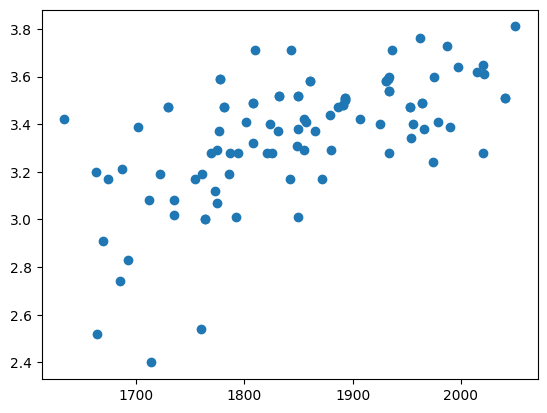

In [ ]:
plt.scatter(df['SAT'],df['GPA'])

In [ ]:
df.corr()

,SAT,GPA
SAT,1.000000,0.612552
GPA,0.612552,1.000000


In [ ]:
# Create models and model functions
linear_model = LinearRegression()
ridge_model = Ridge(random_state=1)
lasso_model = Lasso(random_state=1)
models = [linear_model, ridge_model, lasso_model]

def run_models(array_of_models):
  X=df[['SAT']]
  y=df[['GPA']]
  X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=1)

  for model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    msqrd_err = mean_squared_error(y_test, pred)
    print(f'{model.__class__.__name__} Evaluation')
    print(f'Mean square error is {msqrd_err}')
    print(f'R² score: is {r2_score(y_test, pred)}')

In [ ]:
run_models(models)

LinearRegression Evaluation
Mean square error is 0.04455462858646333
R² score: is -0.25017371783419295
Ridge Evaluation
Mean square error is 0.044554607460155785
R² score: is -0.25017312504382994
Lasso Evaluation
Mean square error is 0.04360514824392339
R² score: is -0.22353192084243712


<Axes: xlabel='SAT', ylabel='GPA'>

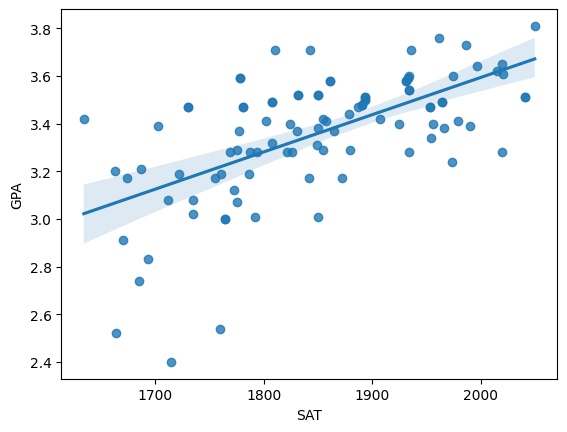

In [ ]:
# See how many outliers there are
sns.regplot(x='SAT', y='GPA', data=df)

In [ ]:
# Clean up the outliers using interquartile range calculations
# Filter out rows with outliers on GPA only
Q1 = df['GPA'].quantile(0.25)
Q3 = df['GPA'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['GPA'] >= Q1 - 1.5 * IQR) & (df['GPA'] <= Q3 + 1.5 * IQR)]

run_models(models)

LinearRegression Evaluation
Mean square error is 0.021054414560541485
R² score: is 0.2736804410722361
Ridge Evaluation
Mean square error is 0.02105441259755458
R² score: is 0.2736805087899007
Lasso Evaluation
Mean square error is 0.021016704893756247
R² score: is 0.27498132115455853


Mean square error was removed by reducing the outliers using the interquartile range function, but ultimately lack of data probably held back the model.

<Axes: xlabel='SAT', ylabel='GPA'>

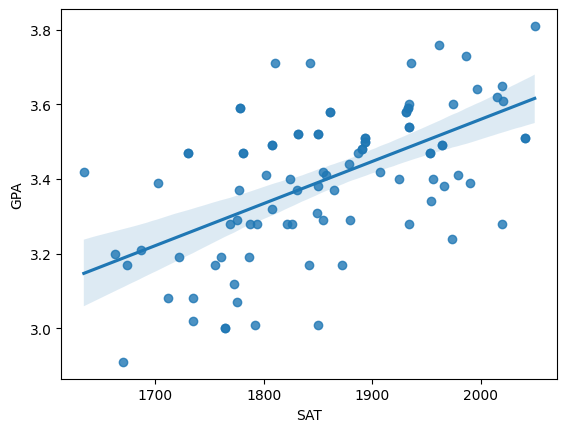

In [ ]:
# See how many outliers there are now
sns.regplot(x='SAT', y='GPA', data=df)